# Phase 2 — LHS Sampling + SWMM Automation Pipeline

Builds a training dataset by running the base SWMM model 100 times under Latin Hypercube-sampled combinations of 5 uncertain parameters.

**Flow:** LHS sample -> edit `base_model.inp` -> run `runswmm.exe` -> parse `.rpt` -> `dataset.csv`.

See design: `docs/superpowers/specs/2026-09-04-phase2-lhs-automation-design.md`.

## 1. Config & paths

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# --- Locate repo root (works whether launched from repo root or /notebooks) ---
def _find_root(marker="PROJECT_BRIEF.md"):
    here = Path.cwd()
    for cand in [here, *here.parents]:
        if (cand / marker).exists():
            return cand
    return here

PROJECT  = _find_root()

# --- Paths ---
# SWMM_EXE is machine-specific: set this to YOUR SWMM install (see README).
SWMM_EXE = Path(r"D:\EPA SWMM 5.2.4 (64-bit)\runswmm.exe")
SWMM_DIR = PROJECT / "swmm"
BASE_INP = SWMM_DIR / "base_model.inp"
RUNS_DIR = PROJECT / "runs"
DATA_DIR = PROJECT / "data"
RUNS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

# --- Experiment settings ---
N_RUNS = 500
SEED   = 42

# --- Uncertain parameters: name -> (low, high) ---
PARAM_RANGES = {
    "rain_mult":   (0.7, 1.5),      # multiply the 2-yr rainfall timeseries
    "imperv_mult": (0.7, 1.3),      # multiply each subcatchment %Imperv (clip 0-100)
    "surf_n":      (0.011, 0.030),  # impervious overland Manning n (absolute)
    "infil_min":   (0.05, 1.5),     # Horton MinRate, in/hr (absolute)
    "pipe_n":      (0.011, 0.030),  # conduit Manning roughness (absolute)
}
PARAM_NAMES = list(PARAM_RANGES)

assert SWMM_EXE.exists(), f"runswmm.exe not found at {SWMM_EXE}"
assert BASE_INP.exists(), f"base_model.inp not found at {BASE_INP}"
print("Config OK. Base model:", BASE_INP.name, "| runs dir:", RUNS_DIR)

Config OK. Base model: base_model.inp | runs dir: D:\Claude\surrogate_modeling\runs


## 2. Latin Hypercube sampling

`scipy.stats.qmc.LatinHypercube` draws 100 points in the 5-D unit cube, then we scale each column to its physical range. A fixed `SEED` makes this reproducible.

In [2]:
from scipy.stats import qmc

sampler = qmc.LatinHypercube(d=len(PARAM_RANGES), seed=SEED)
unit    = sampler.random(n=N_RUNS)              # (N_RUNS, 5) in [0, 1)
lows    = np.array([lo for lo, hi in PARAM_RANGES.values()])
highs   = np.array([hi for lo, hi in PARAM_RANGES.values()])
scaled  = qmc.scale(unit, lows, highs)

samples = pd.DataFrame(scaled, columns=PARAM_NAMES)
samples.index.name = "run_id"
print("LHS samples:", samples.shape)
samples.describe().round(3)

LHS samples: (500, 5)


,rain_mult,imperv_mult,surf_n,infil_min,pipe_n
count,500.000,500.000,500.000,500.000,500.000
mean,1.100,1.000,0.021,0.775,0.020
std,0.231,0.173,0.005,0.419,0.005
min,0.701,0.700,0.011,0.050,0.011
25%,0.900,0.850,0.016,0.413,0.016
50%,1.100,1.000,0.021,0.775,0.020
75%,1.299,1.150,0.025,1.137,0.025
max,1.499,1.300,0.030,1.500,0.030


## 3. Edit the `.inp` per sample

`write_scenario` walks the base `.inp` line by line, tracks the current `[SECTION]`, and rewrites just the relevant token in each data line. Comments and blank lines pass through untouched. The check at the bottom prints exactly which lines changed for sample 0.

In [3]:
def _fmt(x):
    """Compact numeric formatting for .inp tokens."""
    return f"{x:g}"

def write_scenario(base_text, params):
    """Return a modified .inp text with the 5 uncertain parameters applied.

    SWMM .inp files are whitespace-delimited; we edit the relevant token in
    each data line of the target sections and leave comments/blanks as-is.
    """
    rain_mult   = params["rain_mult"]
    imperv_mult = params["imperv_mult"]
    surf_n      = params["surf_n"]
    infil_min   = params["infil_min"]
    pipe_n      = params["pipe_n"]

    out_lines = []
    section = None
    for line in base_text.splitlines():
        stripped = line.strip()

        # Section header, e.g. [SUBCATCHMENTS]
        if stripped.startswith("[") and stripped.endswith("]"):
            section = stripped.upper()
            out_lines.append(line)
            continue
        # Pass through blanks and comments untouched
        if not stripped or stripped.startswith(";"):
            out_lines.append(line)
            continue

        toks = stripped.split()
        modified = None

        if section == "[TIMESERIES]" and toks[0] == "2-yr":
            # cols: Name Time Value  -> scale Value
            toks[-1] = _fmt(float(toks[-1]) * rain_mult)
            modified = toks
        elif section == "[SUBCATCHMENTS]":
            # cols: Name RainGage Outlet Area %Imperv Width %Slope CurbLen
            imp = float(toks[4]) * imperv_mult
            toks[4] = _fmt(min(100.0, max(0.0, imp)))
            modified = toks
        elif section == "[SUBAREAS]":
            # cols: Subcatch N-Imperv N-Perv ...
            toks[1] = _fmt(surf_n)
            modified = toks
        elif section == "[INFILTRATION]":
            # Horton cols: Subcatch MaxRate MinRate Decay DryTime MaxInfil
            toks[2] = _fmt(infil_min)
            modified = toks
        elif section == "[CONDUITS]":
            # cols: Name From To Length Roughness ...
            toks[4] = _fmt(pipe_n)
            modified = toks

        out_lines.append("  ".join(modified) if modified else line)

    return "\n".join(out_lines) + "\n"


# --- Quick check: apply sample 0 and show what changed ---
base_text = BASE_INP.read_text()
demo = write_scenario(base_text, samples.iloc[0].to_dict())

print("Sample 0 params:")
print(samples.iloc[0].round(4).to_string())
print("\nChanged lines (base  ->  scenario):")
for b, s in zip(base_text.splitlines(), demo.splitlines()):
    if b != s:
        print(f"  {b.strip():<45} ->  {s.strip()}")

Sample 0 params:
rain_mult      1.2828
imperv_mult    0.9935
surf_n         0.0254
infil_min      1.1007
pipe_n         0.0198

Changed lines (base  ->  scenario):
  S1               1                J1               4.55     56.8     1587     2        0 ->  S1  1  J1  4.55  56.4293  1587  2  0
  S3               1                J1               3.74     39.5     1456     3.1      0 ->  S3  1  J1  3.74  39.2422  1456  3.1  0
  S2               1                J1               4.74     63       1653     2        0 ->  S2  1  J1  4.74  62.5888  1653  2  0
  S1               0.015      0.24       0.06       0.3        25         OUTLET ->  S1  0.0254074  0.24  0.06  0.3  25  OUTLET
  S3               0.015      0.24       0.06       0.3        25         OUTLET ->  S3  0.0254074  0.24  0.06  0.3  25  OUTLET
  S2               0.015      0.24       0.06       0.3        25         OUTLET ->  S2  0.0254074  0.24  0.06  0.3  25  OUTLET
  S1               4.5        0.2        6.5        7 

## 4. Run SWMM & parse the `.rpt`

`run_swmm` shells out to `runswmm.exe input.inp report.rpt output.out`. `parse_rpt` pulls the three targets + continuity error with regex/section anchors. Note: the **Node Flooding Summary** table is absent when nothing floods, so its absence correctly yields 0 flooded nodes / 0 volume.

In [4]:
import subprocess
import re

def run_swmm(inp_path):
    """Run a scenario through runswmm.exe. Returns (rpt_path, out_path, proc)."""
    inp_path = Path(inp_path)
    rpt_path = inp_path.with_suffix(".rpt")
    out_path = inp_path.with_suffix(".out")
    proc = subprocess.run(
        [str(SWMM_EXE), str(inp_path), str(rpt_path), str(out_path)],
        capture_output=True, text=True,
    )
    return rpt_path, out_path, proc

def parse_rpt(rpt_text):
    """Extract the 3 targets + continuity error from a SWMM .rpt report."""
    res = {
        "peak_discharge_cfs":   np.nan,
        "total_flood_vol":      0.0,
        "num_flooded_nodes":    0,
        "continuity_error_pct": np.nan,
    }
    lines = rpt_text.splitlines()

    # Flow routing continuity error. The .rpt has TWO "Continuity Error (%)" lines
    # (Runoff Quantity + Flow Routing); we want the Flow Routing one, so anchor on
    # that block header first.
    fr = next((i for i, ln in enumerate(lines) if "Flow Routing Continuity" in ln), None)
    if fr is not None:
        for ln in lines[fr:fr + 25]:
            m = re.search(r"Continuity Error \(%\)\s*\.*\s*(-?[\d.]+)", ln)
            if m:
                res["continuity_error_pct"] = float(m.group(1))
                break

    # Flooding loss (10^6 gal) from the Flow Routing Continuity block
    m = re.search(r"Flooding Loss\s*\.*\s*(-?[\d.]+)\s+(-?[\d.]+)", rpt_text)
    if m:
        res["total_flood_vol"] = float(m.group(2))

    # Peak discharge = Max Flow for Out1 in the Outfall Loading Summary
    for i, ln in enumerate(lines):
        if "Outfall Loading Summary" in ln:
            for ln2 in lines[i:i + 25]:
                t = ln2.split()
                if t and t[0] == "Out1":
                    # cols: Node FlowFreq AvgFlow MaxFlow TotalVol
                    res["peak_discharge_cfs"] = float(t[3])
                    break
            break

    # Count flooded nodes in the Node Flooding Summary (absent if no flooding)
    fl = next((i for i, ln in enumerate(lines) if "Node Flooding Summary" in ln), None)
    if fl is not None:
        dashes = 0
        count = 0
        for ln in lines[fl:fl + 80]:
            s = ln.strip()
            if s and set(s) == {"-"}:
                dashes += 1
                continue
            if dashes >= 2:
                if not s:
                    break
                t = ln.split()
                if len(t) >= 6:
                    count += 1
        res["num_flooded_nodes"] = count

    return res


# --- Smoke test on sample 0 ---
demo_inp = RUNS_DIR / "scenario_000.inp"
demo_inp.write_text(demo)
rpt, out, proc = run_swmm(demo_inp)
print("return code:", proc.returncode)
print(parse_rpt(rpt.read_text()))

return code: 0
{'peak_discharge_cfs': 22.98, 'total_flood_vol': 0.001, 'num_flooded_nodes': 1, 'continuity_error_pct': 0.014}


## 5. Batch loop (100 runs)

Each sample is written, run, and parsed. A `try/except` isolates failures so one bad run flags its row instead of crashing the batch. The binary `.out` is deleted after parsing; `.inp`/`.rpt` are kept for auditability.

In [5]:
import time

base_text = BASE_INP.read_text()
rows = []
t0 = time.time()

for run_id, row in samples.iterrows():
    params = row.to_dict()
    inp_path = RUNS_DIR / f"scenario_{run_id:03d}.inp"
    rec = {"run_id": run_id, **params}
    try:
        inp_path.write_text(write_scenario(base_text, params))
        rpt_path, out_path, proc = run_swmm(inp_path)
        if not rpt_path.exists():
            rec["status"] = "failed"
        else:
            rec.update(parse_rpt(rpt_path.read_text()))
            ce = rec.get("continuity_error_pct")
            rec["status"] = "flagged" if (ce is not None and abs(ce) > 5) else "ok"
        if out_path.exists():
            out_path.unlink()           # drop the binary .out to save space
    except Exception as e:
        rec["status"] = "failed"
        rec["error"] = str(e)
    rows.append(rec)
    if (run_id + 1) % 10 == 0:
        print(f"  {run_id + 1}/{N_RUNS} done  ({time.time() - t0:.1f}s)")

results = pd.DataFrame(rows).set_index("run_id")
print(f"\nBatch finished in {time.time() - t0:.1f}s")
print(results["status"].value_counts())

  10/500 done  (0.3s)
  20/500 done  (0.7s)
  30/500 done  (1.0s)
  40/500 done  (1.4s)
  50/500 done  (1.7s)
  60/500 done  (2.1s)
  70/500 done  (2.4s)
  80/500 done  (2.8s)
  90/500 done  (3.1s)
  100/500 done  (3.5s)
  110/500 done  (3.9s)
  120/500 done  (4.3s)
  130/500 done  (4.7s)
  140/500 done  (5.1s)
  150/500 done  (5.5s)
  160/500 done  (5.9s)
  170/500 done  (6.3s)
  180/500 done  (6.7s)
  190/500 done  (7.1s)
  200/500 done  (7.5s)
  210/500 done  (7.9s)
  220/500 done  (8.3s)
  230/500 done  (8.7s)
  240/500 done  (9.2s)
  250/500 done  (9.6s)
  260/500 done  (10.0s)
  270/500 done  (10.4s)
  280/500 done  (10.8s)
  290/500 done  (11.2s)
  300/500 done  (11.6s)
  310/500 done  (12.0s)
  320/500 done  (12.4s)
  330/500 done  (12.8s)
  340/500 done  (13.2s)
  350/500 done  (13.6s)
  360/500 done  (14.0s)
  370/500 done  (14.5s)
  380/500 done  (14.9s)
  390/500 done  (15.2s)
  400/500 done  (15.6s)
  410/500 done  (15.9s)
  420/500 done  (16.3s)
  430/500 done  (16.7s)
  

## 6. Assemble & save `dataset.csv`

Merge features + targets + QC columns, save, then sanity-check: how many runs flooded, the spread of each target, and how peak discharge responds to each input.

Saved dataset.csv: (500, 10)


,rain_mult,imperv_mult,surf_n,infil_min,pipe_n,peak_discharge_cfs,total_flood_vol,num_flooded_nodes,continuity_error_pct,status
run_id,,,,,,,,,,
0,1.282762,0.993473,0.025407,1.100678,0.019812,22.98,0.001,1,0.014,ok
1,0.820039,0.995487,0.012186,1.490928,0.028653,16.02,0.000,0,0.000,ok
2,1.323407,0.829688,0.016980,1.280114,0.019077,21.89,0.000,0,0.029,ok
3,0.773236,0.857734,0.013848,0.189700,0.020742,13.15,0.000,0,0.025,ok
4,0.743587,0.974375,0.023465,0.085110,0.015340,14.11,0.000,0,0.029,ok



Runs OK: 500 | flooded (>0 vol): 176
       peak_discharge_cfs  total_flood_vol  num_flooded_nodes
count             500.000          500.000            500.000
mean               19.285            0.003              0.428
std                 4.419            0.007              0.495
min                10.210            0.000              0.000
25%                16.350            0.000              0.000
50%                18.465            0.000              0.000
75%                21.803            0.003              1.000
max                34.170            0.046              1.000


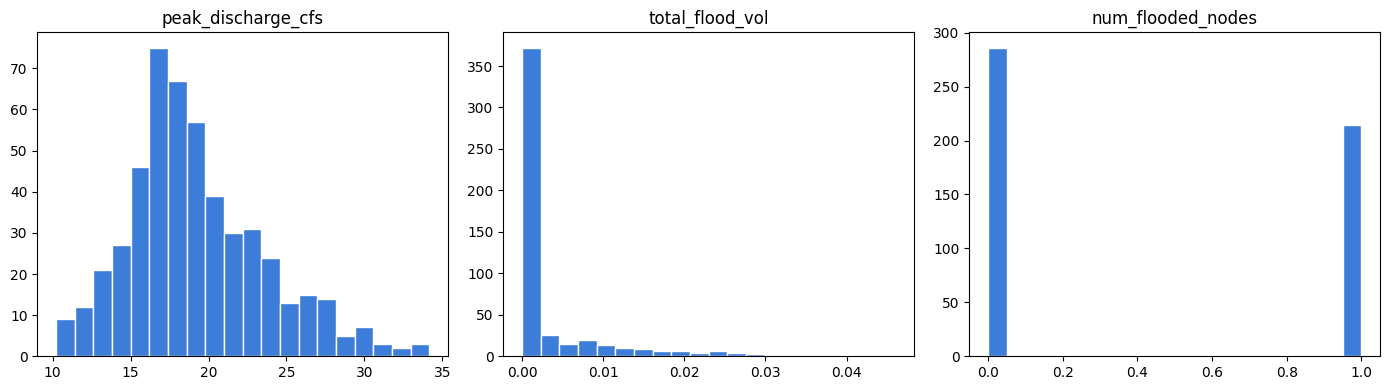

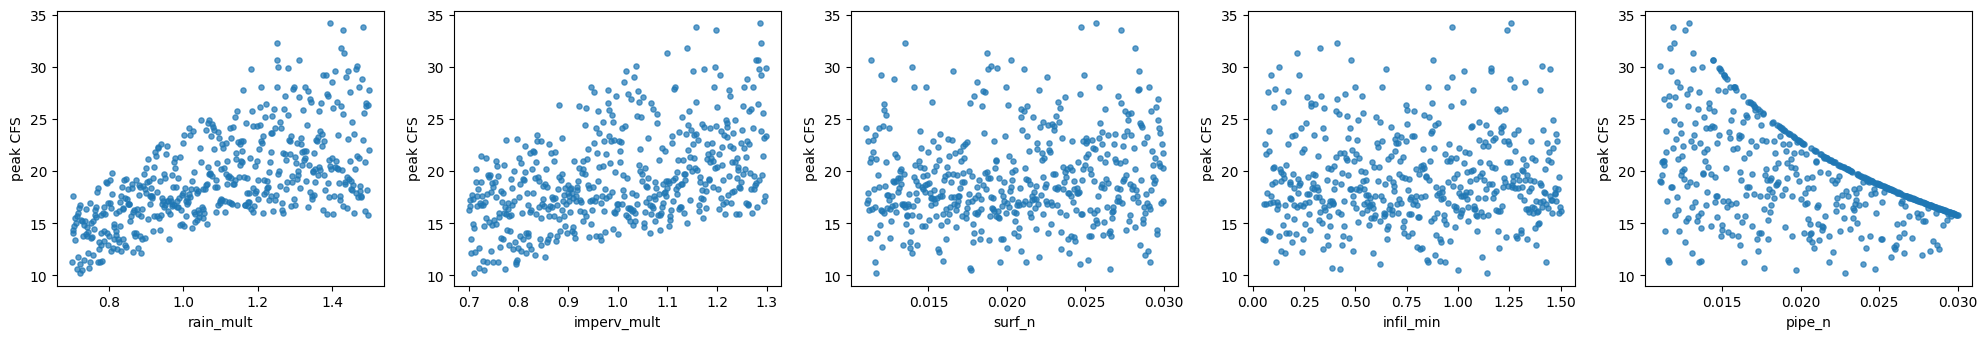

In [6]:
import matplotlib.pyplot as plt

feature_cols = PARAM_NAMES
target_cols  = ["peak_discharge_cfs", "total_flood_vol", "num_flooded_nodes"]
qc_cols      = ["continuity_error_pct", "status"]

dataset = results[feature_cols + target_cols + qc_cols].copy()
dataset.to_csv(DATA_DIR / "dataset.csv")
print("Saved dataset.csv:", dataset.shape)
display(dataset.head())

# Sanity: how many runs flooded? Peak discharge spread?
ok = dataset[dataset["status"] != "failed"]
print(f"\nRuns OK: {len(ok)} | flooded (>0 vol): {(ok['total_flood_vol'] > 0).sum()}")
print(ok[target_cols].describe().round(3))

# Target distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, target_cols):
    ax.hist(ok[col].dropna(), bins=20, color="#3b7dd8", edgecolor="white")
    ax.set_title(col)
plt.tight_layout(); plt.show()

# Each feature vs peak discharge
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, col in zip(axes, feature_cols):
    ax.scatter(ok[col], ok["peak_discharge_cfs"], s=14, alpha=0.7)
    ax.set_xlabel(col); ax.set_ylabel("peak CFS")
plt.tight_layout(); plt.show()

## 7. Learning demo — pyswmm (in-process)

Optional. Reads the *same* peak discharge for run 0 by stepping the simulation in-process, to contrast with the `.rpt` text parsing above. Install first if needed: `pip install pyswmm`.

In [7]:
# Learning demo: read the SAME peak discharge in-process with pyswmm,
# to compare against our .rpt text parsing.
#   If not installed:  pip install pyswmm
try:
    from pyswmm import Simulation, Nodes

    scen = RUNS_DIR / "scenario_000.inp"
    peak = 0.0
    with Simulation(str(scen)) as sim:
        out1 = Nodes(sim)["Out1"]
        for _ in sim:
            peak = max(peak, out1.total_inflow)

    print(f"pyswmm  peak inflow at Out1 : {peak:6.2f} CFS")
    print(f".rpt    parsed peak (run 0) : {results.loc[0, 'peak_discharge_cfs']:6.2f} CFS")
    print("These should match closely (both read the same simulation).")
except ImportError:
    print("pyswmm not installed. To try this learning cell, run:  pip install pyswmm")

pyswmm  peak inflow at Out1 :  22.98 CFS
.rpt    parsed peak (run 0) :  22.98 CFS
These should match closely (both read the same simulation).
